
<p style="font-size:1.25em;"> Ce notebook a pour objectif de fournir rapidement : <br> <strong> Le paramètre d’ordre nématique moyen</strong> <strong>
et les pics de corrélation</strong> à partir d’un dossier contenant des fichiers <strong>H5</strong>. </p>

<span style="font-size: 1.4em; font-weight: 700;"> Fonctionnalités principales</span>
<p style="font-size:1.15em;">

Calcul des intensités moyennes du dossier

Extraction des pics de corrélation

Détermination du paramètre d’ordre sur la valeur de q du premier pic

Importation de l'image de diffusion moyenne,
avec tracé automatique des cercles correspondant aux différents pics

</p>


In [1]:
%matplotlib widget

# Imports standards
import glob
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

# Imports du projet
from saxsprocessor import SAXSProcessor
from filereaders import h5File_SWING

# Imports depuis utilities_SWING
from utilities_SWING import (
    average_h5_intensity,
    compute_global_nematic_parameter,
    save_Iq_to_dat,
    view_position_grid,
    plot_transmission_map
)

# Imports depuis saxs_analysis
from saxs_analysis import SAXSBatch

In [2]:
# ========================================
# CONFIGURATION
# ========================================

# --- Chemins des fichiers ---
h5path = 'T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/20231871/2024/Run3/assemblages/co12_serie/co12_15_1000a/'
mask = 'T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/SwingSoleil-main/mask.edf'

# --- Paramètres de traitement ---
fenetre = (0.02, 0.10)  # Fenêtre en q pour l'analyse (Å⁻¹)
lissage = 40             # Fenêtre de lissage Savitzky-Golay
prefix = 'lacroix'       # Préfixe des fichiers H5

# --- Paramètres de l'échantillon ---
Longueur = 1000          # Longueur des particules (nm)
Diametre = 200           # Diamètre des particules (nm)
Polydispersite_L = 0.2   # Polydispersité en longueur
Polydispersite_D = 0.7   # Polydispersité en diamètre

basler_coords = (186, 309)
basler_calibration = (3.7, 3.7)

## Extraction du sample name

In [3]:
# Lister tous les fichiers H5 du dossier
data = glob.glob(os.path.join(h5path, '*.h5'))

# Extraction du sample name du premier fichier H5
if len(data) > 0:
    first_h5_file = data[0]
    h5_reader = h5File_SWING(first_h5_file, mean=True)
    sample_name = h5_reader.samplename
    print(f"✓ Sample name extrait : {sample_name}")
else:
    sample_name = "unknown"
    print("⚠️ Aucun fichier trouvé, impossible d'extraire le sample name.")

# Créer le dossier de sortie basé sur le sample_name
outputdir = os.path.join(h5path, f"{sample_name}_processed")
os.makedirs(outputdir, exist_ok=True)
print(f"✓ Dossier de sortie créé : {outputdir}")

✓ Sample name extrait : co12_15_1000a
✓ Dossier de sortie créé : T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/20231871/2024/Run3/assemblages/co12_serie/co12_15_1000a/co12_15_1000a_processed


## Cartographie des pointés

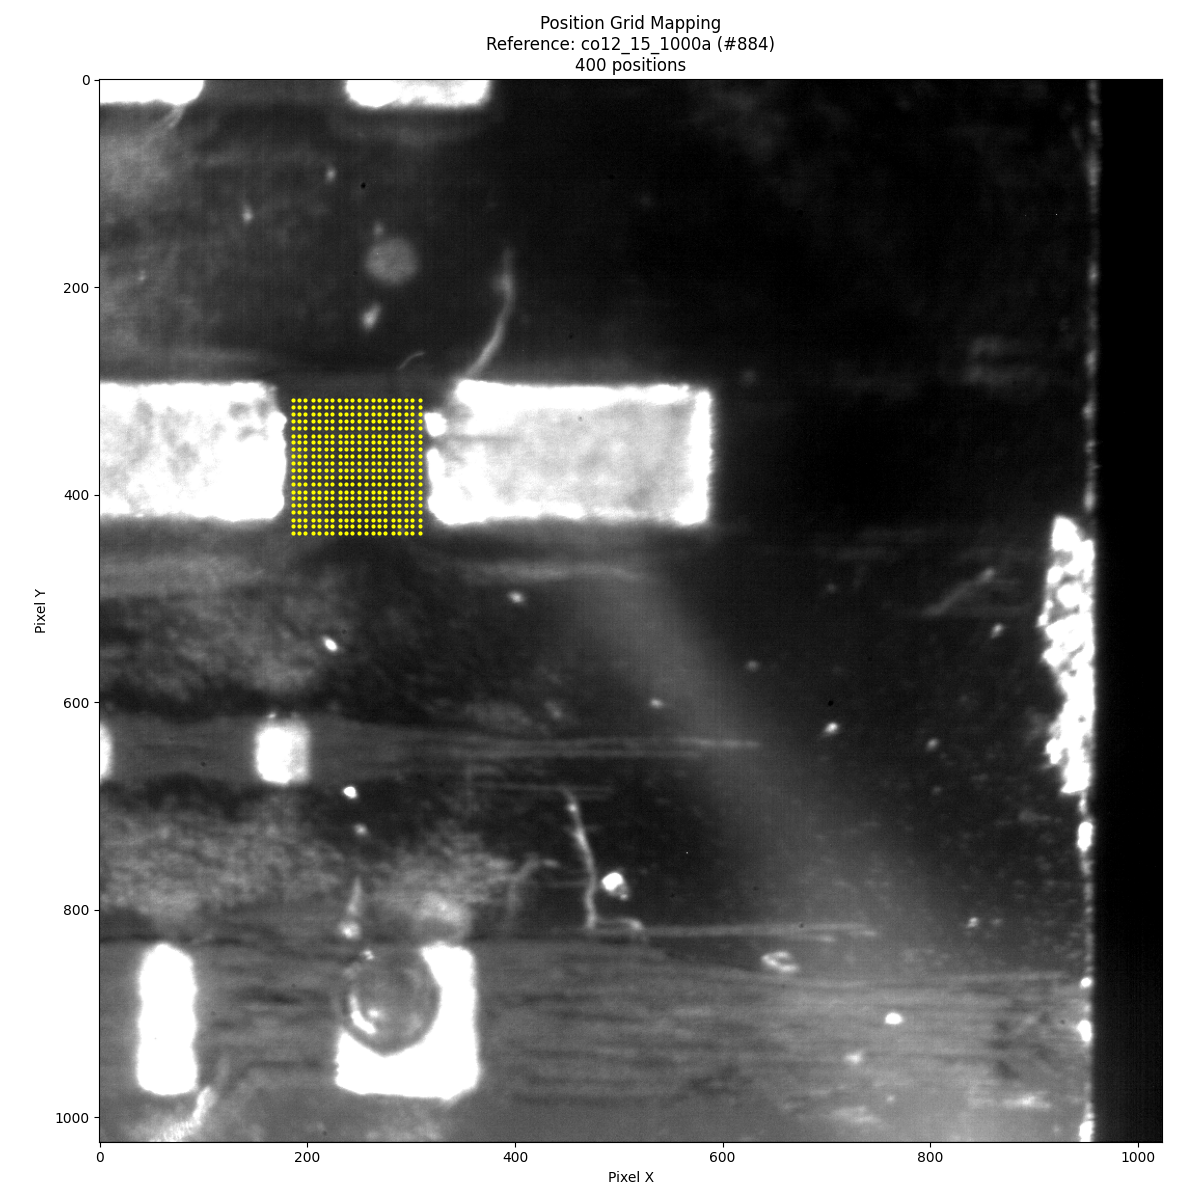


RÉSULTATS
Nombre total de positions: 400
Échantillon de référence: co12_15_1000a
✓ Carte sauvegardée : T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/20231871/2024/Run3/assemblages/co12_serie/co12_15_1000a/co12_15_1000a_processed\co12_15_1000a_position_map.png

Statistiques:
  x_min: 186
  x_max: 308
  x_range: 122
  z_min: 309
  z_max: 437
  z_range: 128
  total_points: 400
  file_range: (884, 903)


In [4]:

position_map_filename = f"{sample_name}_position_map.png"
position_map_path = os.path.join(outputdir, position_map_filename)

# Appeler la fonction avec tous les arguments
results = view_position_grid(
    data_folder=h5path,
    prefix=prefix,  # Préfixe pour fichiers 'lacroix_*.h5'
    basler_coords=basler_coords,
    basler_calibration=basler_calibration,
    reference_file=None,  # Utilise le premier fichier
    marker_size=3,
    marker_color='yellow',
    marker_style='o',
    figsize=(12, 12),
    cmap='gray',
    contrast_adjust=True,  # Mettre True pour ajuster le contraste
    contrast_percentiles=(5, 95),
    plot=True,
    save_image=True,
    output_filename=position_map_path,  # Sauvegarde dans outputdir
    verbose=False
)

# Accéder aux résultats
print(f"\n{'='*60}")
print("RÉSULTATS")
print(f"{'='*60}")
print(f"Nombre total de positions: {results['total_frames']}")
print(f"Échantillon de référence: {results['reference_sample']}")
print(f"✓ Carte sauvegardée : {position_map_path}")
print(f"\nStatistiques:")
for key, value in results['stats'].items():
    print(f"  {key}: {value}")

## Cartographie des transmissions

In [ ]:
transmission_map_filename = f"{sample_name}_transmission_map.png"
transmission_map_path = os.path.join(outputdir, transmission_map_filename)

plot_transmission_map(
    h5path,
    prefix=prefix,
    output_filename=transmission_map_path,
    plot=True  # Afficher le graphique dans le notebook
)

Extracting transmission data:   0%|          | 0/20 [00:00<?, ?it/s]

✓ Carte de transmission sauvegardée : T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/20231871/2024/Run3/assemblages/co12_serie/co12_15_1000a/co12_15_1000a_processed\co12_15_1000a_transmission_map.png


'T:/LPCNO/NCO/Manips/DATA_SAXS/SWING_µSAXS/20231871/2024/Run3/assemblages/co12_serie/co12_15_1000a/co12_15_1000a_processed\\co12_15_1000a_transmission_map.png'

## Calcul de l'intensité moyenne et extraction du profil radial

In [ ]:
## Conversion du profil radial en fichier .dat

# Calcul de l'intensité moyenne du dossier H5
meanInt, nb_files = average_h5_intensity(
    h5path,
    prefix=prefix,
    reference_file=None,  # TODO: Ajouter la référence si nécessaire
    k=1,
    autosubstract=True,
    mask=mask,
    verbose=True
)

# Initialisation du processeur SAXS
processor = SAXSProcessor(
    instrument='SWING',
    reference_file=None,  # TODO: Ajouter la référence si nécessaire
    file=data[0],
    autosubstract=True,
    mask=mask
)
processor.data = meanInt

# Création du dossier de sortie
os.makedirs(outputdir, exist_ok=True)

# Extraction du profil radial
q, I = processor.extract_radial_profile(width=360)

# Visualisation
plt.figure(figsize=(8, 6))
plt.loglog(q, I)
plt.xlabel('q (Å⁻¹)', fontsize=12)
plt.ylabel('I(q)', fontsize=12)
plt.title(f'Profil radial - {sample_name}', fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Utiliser le sample_name extrait du fichier H5 pour nommer le fichier .dat
dat_filename = f"{sample_name}_mean_assembly_intens.dat"
save_Iq_to_dat(I, q, outputdir, filename=dat_filename)


In [ ]:
# Chargement du fichier .dat dans SAXSBatch
batch = SAXSBatch(
    dir_path=outputdir,
    sample_name='',  # Vide pour éviter de créer un sous-dossier
    type='*',
    file_patern=f"{sample_name}.dat",
    sort_key=None
)

batch.loadseq()
print(f"✓ Batch chargé avec {len(batch.experiments)} expérience(s)")

# Visualisation des données brutes
batch.plot(
    subplot=True,
    curves=(['Iq'],),
    plot_type=('loglog',),
    legend=(True,)
)

In [ ]:
# Prétraitement des données
(batch
 .preprocess
 .savgol(window=lissage)
 .up_scale()
 .feat_power_law(average=False, bounds=fenetre, verbose=False)
)

# Application du masque en q
batch.apply_masks(*fenetre)
print(f"✓ Prétraitement terminé (lissage={lissage}, fenêtre={fenetre})")

# Visualisation avant/après prétraitement
batch.plot(
    subplot=True,
    curves=(['Iq'], ['Iq_preprocess']),
    peaks=False,
    plot_type=('loglog', 'semilogx'),
    legend=(True, True)
)

In [ ]:
# Détection des pics
(batch
 .findpeaks
 .standard()
)

print(f"✓ Détection des pics terminée")

# Récupération des positions des pics
for key, exp in batch.experiments.items():
    q_peaks = exp.peaks["Standard"].get("q_values", [])
    print(f"  → {len(q_peaks)} pic(s) détecté(s) : {q_peaks}")

# Visualisation avec les pics
batch.plot(
    subplot=True,
    curves=(['Iq'], ['Iq_preprocess']),
    peaks=True,
    plot_type=('loglog', 'semilogx'),
    legend=(True, False)
)



In [ ]:
processor.plot2d_vsq(q_range=(0,0.15), q_circles=q_peaks, output_dir=outputdir)

## Calcul du paramètre d'ordre nématique

In [ ]:
S = compute_global_nematic_parameter(
    h5path,
    prefix=prefix,
    reference_file=None,
    k=1,
    autosubstract=True,
    mask=None,
    qvalue=q_peaks[0],
    threshold=0.05,
    radius=Diametre/2,
    L=Longueur,
    radius_pd=Polydispersite_D/2,
    L_pd=Polydispersite_L,
    plot=True,
    apply_mirror=False,
    verbose=True)

In [ ]:
rows = []

for key, exp in batch.experiments.items():
    name = exp.name

    order_bg = exp.metadata['power_law_order'] 

    # --- Pics ---
    if "Standard" not in exp.peaks:
        print(f"[SKIP] {name} → no Standard peaks")
        continue

    q_peaks = exp.peaks["Standard"].get("q_values", [])

    if len(q_peaks) == 0:
        print(f"[SKIP] {name} → no peaks detected")
        continue

    # --- Ligne Excel ---
    row = {
        #"fenetre": fenetre,
        "Sample name": sample_name,
        "Nom fichier": name,

        "q Pic 1": q_peaks[0],
        "parametre d'ordre" : S, 
        
        "ordre background": order_bg,
        "distance (nm)": 2 * np.pi / (q_peaks[0] * 10)
    }

    rows.append(row)

# --- DataFrame final ---
df = pd.DataFrame(rows)
df

# To do: 
- ~~Inclure save_Iq_to_dat dans utilities_SWING.py~~ ✅ **FAIT**
- ~~Utiliser le sample_name pour nommer le fichier .dat~~ ✅ **FAIT**
- ~~h5_to_dat_name n'est plus nécessaire~~ ✅ **SUPPRIMÉ**
- Faire une fonction pour ajouter nom de fichier, S et distance dans un fichier.csv
- Réfléchir à une fonction batch pour faire tourner ce notebook sur plusieurs dossiers